## Section 9: Final Model Evaluation and Conclusion

### Model Evaluation

Having trained and tuned two classical models (Random Forest, XGBoost) and one Neural Network (MLP), we now perform a final comparative analysis.

This notebook will:
- Compare models using MAE, RMSE, and R² metrics.
- Analyze error distribution across different Challenge Rating tiers.
- Discuss the trade-offs between model complexity and predictive power.
- Provide a final recommendation for implementation.

In [1]:
import pandas as pd
import numpy as np
import joblib
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# HELPER FUNCTIONS
def get_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred)
    }

def within_n_cr(y_true, y_pred, n=1):
    return np.mean(np.abs(y_true - y_pred) <= n)

In this cell we load the data as well as the CR predictor from the NN notebook -- this is so that the notebook is fully self-contained and reproducible without needing to run the other notebooks first.

In [3]:

X_test = pd.read_csv('../data/final_split/X_test_nn.csv')
y_test = pd.read_csv('../data/final_split/y_test_nn.csv').values.ravel()


class CRPredictor(nn.Module): # todo: maybe make a separate file for this?
    """
    Feedforward MLP for predicting D&D monster Challenge Rating.
    
    Args:
        input_dim:     Number of input features (27)
        hidden_layers: Tuple of neuron counts per hidden layer, e.g. (128, 64, 32)
        dropout:       Dropout rate applied after each hidden layer
    """
    
    def __init__(self, input_dim, hidden_layers=(128, 64, 32), dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for neurons in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, neurons),
                nn.BatchNorm1d(neurons),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = neurons
        
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

Now in this cell, we load all the models -- both their baseline and their tuned versions for testing

In [4]:
# classical tuned
rf_model = joblib.load('../models/classical_tuned/tuned_rf_model.pkl')
xgb_model = joblib.load('../models/classical_tuned/tuned_xgb_model.pkl')

# classical baseline
baseline_rf  = joblib.load('../models/classical_baseline/baseline_rf_model.pkl')
baseline_xgb = joblib.load('../models/classical_baseline/baseline_xgb_model.pkl')

# NN tuned
model_nn = CRPredictor(
    input_dim=X_test.shape[1],
    hidden_layers=(128, 64, 32),  
    dropout=0.3  
)
model_nn.load_state_dict(torch.load('../models/nn_tuned/nn_tuned.pth'))
model_nn.eval()

# NN baseline
model_nn_baseline = CRPredictor(input_dim=X_test.shape[1], hidden_layers=(128, 64, 32), dropout=0.3)
model_nn_baseline.load_state_dict(torch.load('../models/nn_baseline/nn_baseline.pth'))
model_nn_baseline.eval()

print("All models loaded successfully.")

All models loaded successfully.


In here we gather all the predictions using our saved models

In [5]:
x_test_t = torch.tensor(X_test.values, dtype=torch.float32)

rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

with torch.no_grad():
    nn_preds = model_nn(x_test_t).numpy().ravel()

baseline_rf_preds  = baseline_rf.predict(X_test)
baseline_xgb_preds = baseline_xgb.predict(X_test)

with torch.no_grad():
    baseline_nn_preds = model_nn_baseline(x_test_t).numpy().ravel()
    
results_df = pd.DataFrame({
    'Actual': y_test,
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds,
    'Neural Network': nn_preds
})

print("Predictions generated for all models.")


Predictions generated for all models.


we first compare the tuned models to see which has the best performance. In our case, we have XGBoost as the uncontested best.

In [6]:
comparison_table = pd.DataFrame({
    'Random Forest':  get_metrics(y_test, rf_preds),
    'XGBoost':        get_metrics(y_test, xgb_preds),
    'Neural Network': get_metrics(y_test, nn_preds)
}).T

print("Global Model Performance")
display(comparison_table.round(4))

print(f"\nBest MAE:  {comparison_table['MAE'].idxmin()}")
print(f"Best RMSE: {comparison_table['RMSE'].idxmin()}")
print(f"Best R²:   {comparison_table['R2'].idxmax()}")

Global Model Performance


,MAE,RMSE,R2
Random Forest,0.8819,1.3562,0.9511
XGBoost,0.8531,1.3279,0.9531
Neural Network,0.9351,1.4369,0.9451



Best MAE:  XGBoost
Best RMSE: XGBoost
Best R²:   XGBoost


For a better and more visual comparison, here is a bar chart showing the MAE and RMSE between the models

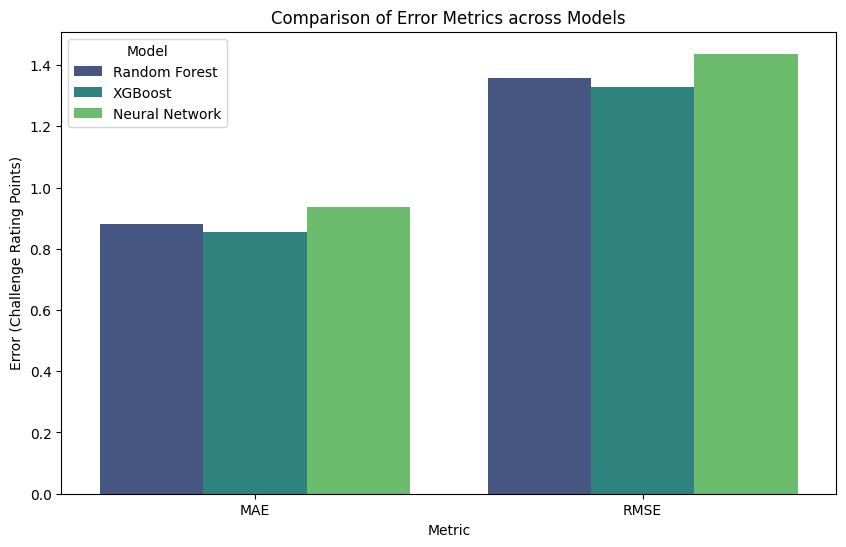

In [7]:
metrics_melted = comparison_table.reset_index().melt(
    id_vars='index', value_vars=['MAE', 'RMSE']
)
metrics_melted.columns = ['Model', 'Metric', 'Value']

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('Comparison of Error Metrics across Models')
plt.ylabel('Error (Challenge Rating Points)')
plt.show()

Now lets check how big the impact of hyperparameter tuning was towards our models. 

In [8]:

tuning_comparison = pd.DataFrame({
    'RF (baseline)':   get_metrics(y_test, baseline_rf_preds),
    'RF (tuned)':      get_metrics(y_test, rf_preds),
    'XGB (baseline)':  get_metrics(y_test, baseline_xgb_preds),
    'XGB (tuned)':     get_metrics(y_test, xgb_preds),
    'NN (baseline)':   get_metrics(y_test, baseline_nn_preds),
    'NN (tuned)':      get_metrics(y_test, nn_preds),
}).T

print("Impact of Hyperparameter Tuning")
display(tuning_comparison.round(4))

for label, base_p, tuned_p in [
    ("Random Forest",   baseline_rf_preds,  rf_preds),
    ("XGBoost",         baseline_xgb_preds, xgb_preds),
    ("Neural Network",  baseline_nn_preds,  nn_preds),
]:
    delta = mean_absolute_error(y_test, base_p) - mean_absolute_error(y_test, tuned_p)
    direction = "better" if delta > 0 else "worse"
    print(f"{label}: MAE changed by {abs(delta):.4f} ({direction} after tuning)")

Impact of Hyperparameter Tuning


,MAE,RMSE,R2
RF (baseline),0.8902,1.3670,0.9503
RF (tuned),0.8819,1.3562,0.9511
XGB (baseline),0.9035,1.4105,0.9471
XGB (tuned),0.8531,1.3279,0.9531
NN (baseline),1.0087,1.5908,0.9328
NN (tuned),0.9351,1.4369,0.9451


Random Forest: MAE changed by 0.0083 (better after tuning)
XGBoost: MAE changed by 0.0504 (better after tuning)
Neural Network: MAE changed by 0.0735 (better after tuning)


The KDE (Kernel Density Estimation) plot and residual statistics below show us the shape of each model's errors. 

not just how big they are on average, but whether errors are:
- symmetric, 
- which direction they lean, 
- and whether any model produces more extreme failures. 

A well-behaved model should have errors centered near zero with no heavy tail in either direction. Our current implementation shows this.

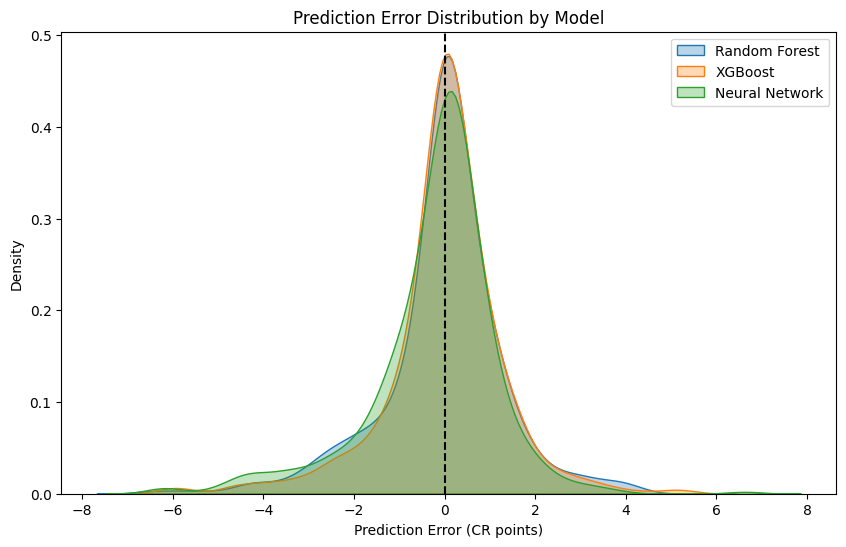

Residual Statistics
Random Forest:  mean=-0.0388  std=1.3571  max=4.2600  min=-6.4943
XGBoost:  mean=-0.0162  std=1.3292  max=5.2670  min=-6.1289
Neural Network:  mean=-0.2302  std=1.4198  max=6.6224  min=-6.2318


In [9]:
plt.figure(figsize=(10, 6))
for col in ['Random Forest', 'XGBoost', 'Neural Network']:
    sns.kdeplot(results_df[col] - results_df['Actual'], label=col, fill=True, alpha=0.3)
plt.axvline(0, color='black', linestyle='--')
plt.title('Prediction Error Distribution by Model')
plt.xlabel('Prediction Error (CR points)')
plt.legend()
plt.show()

print("Residual Statistics")
for col in ['Random Forest', 'XGBoost', 'Neural Network']:
    r = results_df[col] - results_df['Actual']
    print(f"{col}:  mean={r.mean():.4f}  std={r.std():.4f}  max={r.max():.4f}  min={r.min():.4f}")

Now we use a scatter plot to search for **heteroscedasticity** wherein prediction variance increases with CR. The funnel shape proves this. 
>A well-calibrated model would show residuals evenly spread around zero across the full CR range; a funnel shape indicates the model becomes less reliable at higher values.

1. At CR 5 and below, models are highly reliable (residuals cluster near 0). 
2. At CR 15+, errors spread ±5 CR points, meaning the model may be off by an entire difficulty tier. 

    - This is consistent with the boss-tier MAE results and suggests that ensemble models learn the low-CR distribution well, but lack sufficient training signal for rare high-CR monsters.

Notably, residuals skew negative at high predicted values -- the models systematically **under-predict** powerful monsters. A DM using this tool for a CR 20+ boss should expect the tool to suggest a lower CR than the actual one.

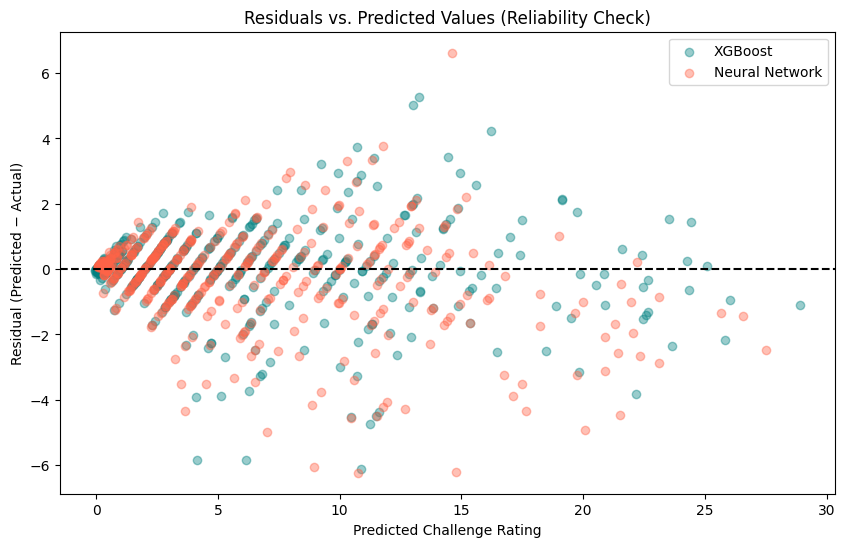

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(xgb_preds, xgb_preds - y_test, alpha=0.4, color='teal',  label='XGBoost')
plt.scatter(nn_preds,  nn_preds  - y_test, alpha=0.4, color='tomato', label='Neural Network')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals vs. Predicted Values (Reliability Check)')
plt.xlabel('Predicted Challenge Rating')
plt.ylabel('Residual (Predicted − Actual)')
plt.legend()
plt.show()

The following bias direction chart categorizes each prediction as accurate (within ±0.5 CR), over-predicted, or under-predicted. 

This matters because systematic directional bias has practical consequences. 
- a tool that consistently over-predicts CR makes homebrew monsters seem stronger than they are
- under-prediction makes them seem weaker, potentially creating unbalanced encounters.

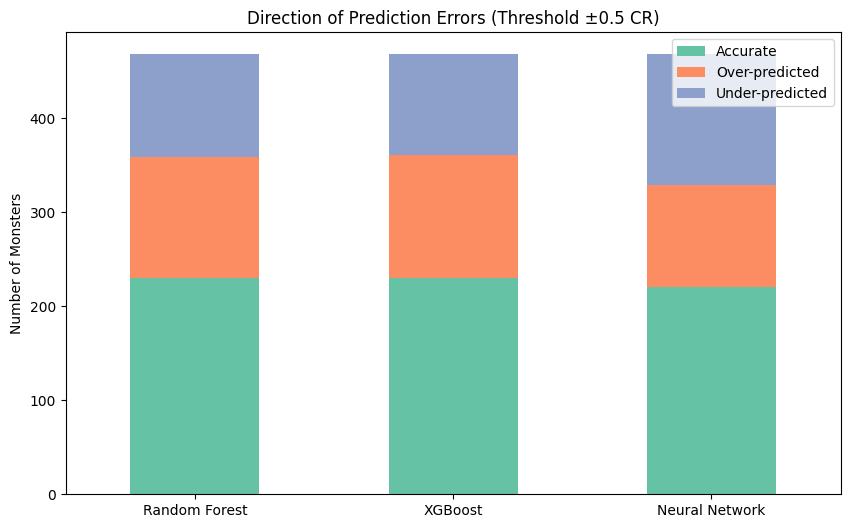

Prediction Direction Counts:


,Accurate,Over-predicted,Under-predicted
Random Forest,230,129,109
XGBoost,230,131,107
Neural Network,221,108,139



As percentages:


,Accurate,Over-predicted,Under-predicted
Random Forest,49.1,27.6,23.3
XGBoost,49.1,28.0,22.9
Neural Network,47.2,23.1,29.7


In [11]:
bias_df = pd.DataFrame()
for model_name in ['Random Forest', 'XGBoost', 'Neural Network']:
    errors = results_df[model_name] - results_df['Actual']
    bias_df[model_name] = [
        'Under-predicted' if x < -0.5 else 'Over-predicted' if x > 0.5 else 'Accurate'
        for x in errors
    ]

bias_summary = bias_df.apply(pd.Series.value_counts).T

bias_summary.plot(kind='bar', stacked=True, figsize=(10, 6),
                  color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title('Direction of Prediction Errors (Threshold ±0.5 CR)')
plt.ylabel('Number of Monsters')
plt.xticks(rotation=0)
plt.show()

print("Prediction Direction Counts:")
display(bias_summary)
print("\nAs percentages:")
display((bias_summary.div(bias_summary.sum(axis=1), axis=0) * 100).round(1))

All three models are roughly balanced between over- and under-prediction for most monsters, with about 48% of predictions falling within ±0.5 CR for both RF and XGBoost. 

However, the Neural Network shows a notably higher under-prediction rate (29.7%) compared to RF (23.3%) and XGBoost (22.9%), which aligns with its larger negative mean residual of −0.23. This confirms the NN has a stronger systematic bias toward guessing lower CRs, especially for powerful monsters.

Following that, we proceed with a tier analysis to check for which "tier" has the highest error. It being the bosses tier aligns with our prior discoveries.

MAE by Monster Tier


,Random Forest,XGBoost,Neural Network
Tier,,,
0-1 (Minions),0.259,0.282,0.294
1-5 (Low),0.651,0.605,0.663
5-10 (Mid),1.302,1.323,1.260
10-20 (High),1.642,1.584,1.659
20+ (Bosses),1.566,1.282,2.509


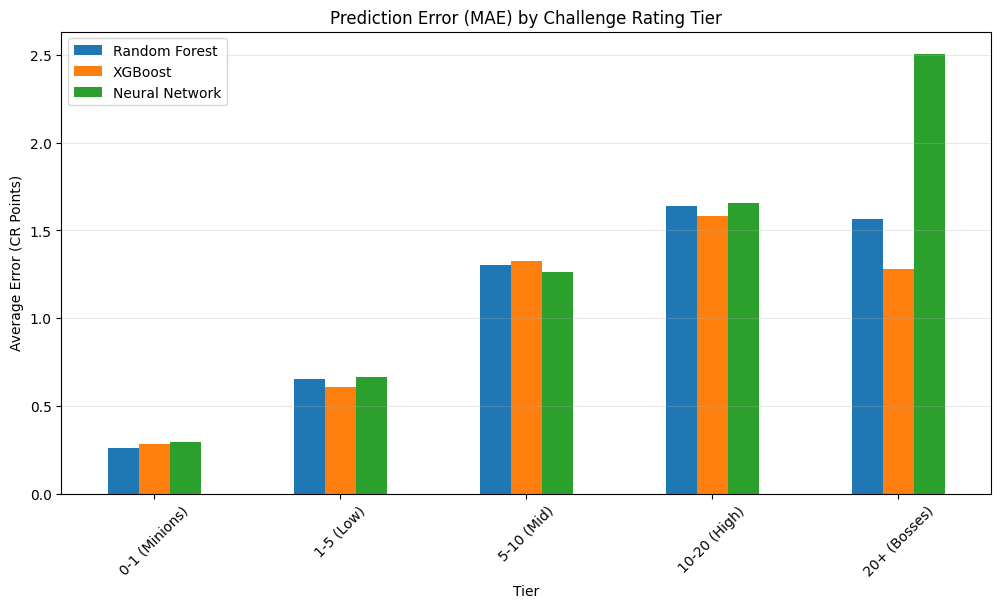

In [12]:
bins = [-np.inf, 1, 5, 10, 20, np.inf]
labels = ['0-1 (Minions)', '1-5 (Low)', '5-10 (Mid)', '10-20 (High)', '20+ (Bosses)']
results_df['Tier'] = pd.cut(results_df['Actual'], bins=bins, labels=labels)

tier_mae = pd.DataFrame()
for model in ['Random Forest', 'XGBoost', 'Neural Network']:
    tier_mae[model] = results_df.groupby('Tier', observed=False).apply(
        lambda x: mean_absolute_error(x['Actual'], x[model])
    )

print("MAE by Monster Tier")
display(tier_mae.round(3))

tier_mae.plot(kind='bar', figsize=(12, 6))
plt.title('Prediction Error (MAE) by Challenge Rating Tier')
plt.ylabel('Average Error (CR Points)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


In here we come back to the within 1 cr accuracy test we previously did, just copied for easier access

In [13]:
print("Within 1 CR Accuracy:")
for name, preds in [("Random Forest", rf_preds), ("XGBoost", xgb_preds), ("Neural Network", nn_preds)]:
    print(f"  {name}: {within_n_cr(y_test, preds, n=1):.1%}")

print("\nWithin 2 CR Accuracy:")
for name, preds in [("Random Forest", rf_preds), ("XGBoost", xgb_preds), ("Neural Network", nn_preds)]:
    print(f"  {name}: {within_n_cr(y_test, preds, n=2):.1%}")

Within 1 CR Accuracy:
  Random Forest: 68.8%
  XGBoost: 71.4%
  Neural Network: 69.0%

Within 2 CR Accuracy:
  Random Forest: 87.6%
  XGBoost: 89.1%
  Neural Network: 87.8%


Now this is the cool stuff, here we look into what exactly were causing the errors, so we do a feature investigation 

In [14]:
outlier_analysis = X_test.copy()
outlier_analysis['Actual']    = y_test
outlier_analysis['RF_Pred']   = rf_preds
outlier_analysis['XGB_Pred']  = xgb_preds
outlier_analysis['NN_Pred']   = nn_preds
outlier_analysis['RF_Error']  = np.abs(rf_preds  - y_test)
outlier_analysis['XGB_Error'] = np.abs(xgb_preds - y_test)
outlier_analysis['NN_Error']  = np.abs(nn_preds  - y_test)

The tables below show the 10 monsters each model struggled with most. The actual monster names aren't in our feature data (we removed them during preprocessing), but the feature profiles tell us what made them difficult.

In [15]:

for model_name, pred_col, error_col in [
    ("Random Forest", "RF_Pred", "RF_Error"),
    ("XGBoost", "XGB_Pred", "XGB_Error"),
    ("Neural Network", "NN_Pred", "NN_Error"),
]:
    top_errors = outlier_analysis.sort_values(by=error_col, ascending=False).head(10)
    print(f"=== Top 10 {model_name} Errors ===")
    display(top_errors[["Actual", pred_col, error_col,
                         "Size_Rank", "Constitution_Z", "Strength_Z", "Log_Avg_HP", "AC_Z"]])
    print()

=== Top 10 Random Forest Errors ===


,Actual,RF_Pred,RF_Error,Size_Rank,Constitution_Z,Strength_Z,Log_Avg_HP,AC_Z
463,17.0,10.505714,6.494286,4,1.118477,1.645513,5.141664,1.792507
450,16.0,10.080000,5.920000,5,-0.076089,2.311768,5.323010,-0.568671
199,15.0,9.719967,5.280033,3,0.640651,0.812693,5.036953,0.105951
223,23.0,18.530000,4.470000,6,1.835217,1.312385,5.579730,1.455196
20,8.0,3.552002,4.447998,3,-0.315002,-0.686382,4.077537,0.105951
280,19.0,14.730000,4.270000,6,1.357391,1.645513,5.451038,0.780574
431,8.0,12.260000,4.260000,6,2.313044,2.145204,5.429346,0.780574
416,16.0,11.915000,4.085000,5,2.074131,0.812693,5.379897,1.117885
339,10.0,5.960000,4.040000,3,0.162824,-0.186690,4.510860,1.117885
144,12.0,16.000000,4.000000,5,1.118477,1.145821,5.579730,0.780574



=== Top 10 XGBoost Errors ===


,Actual,XGB_Pred,XGB_Error,Size_Rank,Constitution_Z,Strength_Z,Log_Avg_HP,AC_Z
463,17.0,10.871132,6.128868,4,1.118477,1.645513,5.141664,1.792507
250,12.0,6.146272,5.853728,4,1.118477,1.312385,5.062595,-0.231360
183,10.0,4.154161,5.845839,4,1.118477,1.145821,5.187386,0.780574
431,8.0,13.267025,5.267025,6,2.313044,2.145204,5.429346,0.780574
176,8.0,13.020164,5.020164,3,-0.553916,-0.852945,4.709530,-0.231360
450,16.0,11.263042,4.736958,5,-0.076089,2.311768,5.323010,-0.568671
199,15.0,10.460347,4.539653,3,0.640651,0.812693,5.036953,0.105951
416,16.0,11.489837,4.510163,5,2.074131,0.812693,5.379897,1.117885
133,16.0,11.622994,4.377006,3,1.118477,0.812693,5.252273,0.780574
206,12.0,16.234383,4.234383,4,0.162824,0.979257,5.036953,1.792507



=== Top 10 Neural Network Errors ===


,Actual,NN_Pred,NN_Error,Size_Rank,Constitution_Z,Strength_Z,Log_Avg_HP,AC_Z
176,8.0,14.622437,6.622437,3,-0.553916,-0.852945,4.709530,-0.231360
463,17.0,10.768220,6.231780,4,1.118477,1.645513,5.141664,1.792507
379,21.0,14.779881,6.220119,3,0.162824,-0.686382,4.912655,0.780574
199,15.0,8.949064,6.050936,3,0.640651,0.812693,5.036953,0.105951
250,12.0,7.021413,4.978587,4,1.118477,1.312385,5.062595,-0.231360
152,25.0,20.061983,4.938017,4,2.551957,2.145204,6.070738,2.467130
425,15.0,10.450814,4.549186,5,1.118477,1.478949,5.278115,-0.905982
450,16.0,11.516191,4.483809,5,-0.076089,2.311768,5.323010,-0.568671
132,26.0,21.533567,4.466433,6,2.551957,2.145204,6.285998,2.467130
20,8.0,3.643834,4.356166,3,-0.315002,-0.686382,4.077537,0.105951


TODO: i feel like this entire cell is off

`Log_Avg_HP` is a log-transformed version of average HP. A high value here means the monster has a lot of hit points. TODO: we saw that there was a high correlation with CR in previous sections, but _____ (high correlation also means high correlation of error? how to word better)
The models struggle most with monsters that have high HP but a CR that doesn't fully reflect it. 

This is typically because their CR is being driven by other mechanics like legendary actions, special abilities, or high damage output that our feature set doesn't capture directly.

`Constitution_Z` and `Strength_Z` rank second and third, which is consistent: both stats directly influence HP and melee damage, so monsters with extreme constitution or strength also tend to fall outside the patterns the model learned from more typical creatures.

In [16]:
print("Correlation between Prediction Error and all features:")
feature_cols = list(X_test.columns)

corr_results = pd.DataFrame({
    'XGB_Error_Corr': [outlier_analysis['XGB_Error'].corr(outlier_analysis[f]) for f in feature_cols],
    'NN_Error_Corr':  [outlier_analysis['NN_Error'].corr(outlier_analysis[f]) for f in feature_cols],
    'RF_Error_Corr':  [outlier_analysis['RF_Error'].corr(outlier_analysis[f]) for f in feature_cols],
}, index=feature_cols)

corr_results['Avg_Corr'] = corr_results.mean(axis=1)
display(corr_results.sort_values('Avg_Corr', ascending=False).round(4))

Correlation between Prediction Error and all features:


,XGB_Error_Corr,NN_Error_Corr,RF_Error_Corr,Avg_Corr
Log_Avg_HP,0.4471,0.4661,0.4757,0.4630
Constitution_Z,0.3973,0.3892,0.4058,0.3974
Strength_Z,0.3447,0.3173,0.3732,0.3451
Size_Rank,0.3324,0.2776,0.3721,0.3274
AC_Z,0.2412,0.2957,0.2771,0.2713
Wisdom_Z,0.1933,0.3012,0.2150,0.2365
Action_Count_MM,0.1856,0.1967,0.2392,0.2072
Trait_Count_MM,0.1955,0.1946,0.1900,0.1934
Is_Legendary,0.1668,0.2220,0.1639,0.1842
Charisma_Z,0.1014,0.2412,0.1167,0.1531


The continuous feature correlations above cover standardized stats. The table below extends this analysis to binary flags and one-hot encoded type columns, showing which categorical identities are associated with systematically higher or lower prediction error.

The results are striking. `Is_Legendary` has the largest positive impact across all models 
-  legendary monsters produce ~0.60 higher MAE for RF and XGBoost, and ~0.86 higher for the NN.  
- `Type_fiend`, `Type_undead`, and `Type_dragon` also increase error, which makes sense: these types contain the game's most powerful and mechanically complex creatures (pit fiends, liches, ancient dragons).


Equally interesting is the negative side: `Type_beast` and `is_swarm` are associated with lower error (−0.56 and −0.40 for XGBoost respectively). 
- Beasts and swarms have the simplest stat blocks in D&D with them having no spellcasting, no legendary actions, and straightforward physical stats. 
- This makes them the easiest monsters for all three models to predict correctly.



In [17]:
binary_features = [
    'Is_Legendary', 'Is_Spellcaster', 'is_swarm',
    'Type_aberration', 'Type_beast', 'Type_construct',
    'Type_dragon', 'Type_elemental', 'Type_fiend',
    'Type_giant', 'Type_humanoid', 'Type_monstrosity',
    'Type_other', 'Type_undead',
]

rows = []
for feat in binary_features:
    for model_err in ['XGB_Error', 'RF_Error', 'NN_Error']:
        group0 = outlier_analysis.loc[outlier_analysis[feat] == 0, model_err]
        group1 = outlier_analysis.loc[outlier_analysis[feat] == 1, model_err]
        if len(group1) == 0:
            continue
        rows.append({
            'Feature':      feat,
            'Model':        model_err.replace('_Error', ''),
            'Mean_Error_0': group0.mean(),
            'Mean_Error_1': group1.mean(),
            'Diff (1-0)':   group1.mean() - group0.mean(),
            'Count_1':      len(group1),
        })

binary_df = pd.DataFrame(rows)

# Pivot so each feature has one row, columns = models
pivot = binary_df.pivot_table(
    index=['Feature', 'Count_1'],
    columns='Model',
    values='Diff (1-0)'
).round(3)
pivot.columns.name = 'Mean error increase when flag=1 vs flag=0'
print("Binary Feature Impact on Prediction Error")
print("Positive = that flag is associated with HIGHER error")
display(pivot.sort_values('XGB', ascending=False))

Binary Feature Impact on Prediction Error
Positive = that flag is associated with HIGHER error


,Mean error increase when flag=1 vs flag=0,NN,RF,XGB
Feature,Count_1,,,
Is_Legendary,41,0.857,0.597,0.600
Type_fiend,24,0.285,0.304,0.404
Type_undead,51,0.579,0.212,0.302
Type_dragon,24,0.278,0.197,0.266
Type_construct,41,0.152,0.150,0.175
Type_giant,22,0.177,0.326,0.154
Type_elemental,14,-0.147,0.146,0.138
Type_monstrosity,54,-0.059,0.235,0.127
Type_other,36,0.181,-0.096,0.083


The three monsters that every model got wrong by more than 4 CR points are shown below. 

What's notable about them is **what they don't have**: 
1. none are legendary (Is_Legendary = 0), despite their high CR.
2. their HP values are moderate rather than extreme, with all having an avg log HP between 5.0 and 5.3 (around 150-200 actual HP) which is well within the range of a 8-12 CR monster
3. All three have actual CRs of 15–17 but were predicted in the 9–12 range. 
4. no extreme stats 

These monsters likely achieve their high CR through multiattack patterns, high damage per round, or special traits that aren't fully represented in the features we engineered (evil and intimidating textual features) -- which points directly to what future work should address.

In [18]:
threshold = 4.0
common_outliers = outlier_analysis[
    (outlier_analysis['RF_Error']  > threshold) &
    (outlier_analysis['XGB_Error'] > threshold) &
    (outlier_analysis['NN_Error']  > threshold)
]

print(f"Hard-to-Predict Monsters (error > {threshold} across all models): {len(common_outliers)}")
top_features = corr_results['Avg_Corr'].abs().sort_values(ascending=False).head(10).index.tolist()

display(common_outliers[
    ['Actual', 'XGB_Pred', 'RF_Pred', 'NN_Pred'] + top_features
].reset_index())

Hard-to-Predict Monsters (error > 4.0 across all models): 3


,index,Actual,XGB_Pred,RF_Pred,NN_Pred,Log_Avg_HP,Constitution_Z,Strength_Z,Size_Rank,AC_Z,Wisdom_Z,Action_Count_MM,Trait_Count_MM,Is_Legendary,Type_beast
0,199,15.0,10.460347,9.719967,8.949064,5.036953,0.640651,0.812693,3,0.105951,1.182886,0.375,0.125,0,0
1,450,16.0,11.263042,10.080000,11.516191,5.323010,-0.076089,2.311768,5,-0.568671,-1.351969,0.375,0.000,0,0
2,463,17.0,10.871132,10.505714,10.768220,5.141664,1.118477,1.645513,4,1.792507,-0.225367,0.375,0.125,0,0


### Discussion of Findings

#### The Superiority of Tree Ensembles
The XGBoost model (R²: 0.953) outperformed the Neural Network across almost all tiers. 
- This is likely due to the Ordinal and Tabular Nature of the dataset. 
- As seen from our EDA and feature importance charts, D&D Challenge Ratings seem to follow a "step-function" logic where certain stat thresholds (like HP ranges) trigger specific CR increases. 
- Decision trees are naturally suited to capture these discrete boundaries better than the continuous activation functions of a Neural Network.

#### Performance of the Neural Network:
The Neural Network (MLP) performed similarly, but got exponentially worse at higher CRs.
- While the MLP used Huber Loss to handle outliers, it likely struggled compared to the tree-ensembles due to the relatively small dataset size (~2,000 samples). Neural networks typically require more data to outperform tuned gradient-boosted trees on structured data.

#### Data Scarcity and Feature Gaps
All models exhibit a sharp performance drop at CR 15+. 
1. Training data is scarce at high CR: only 193 monsters (5.3%) exceed CR 19, so the model has very few examples to learn from in that range. 
    - Predictions in that tier are extrapolations beyond the training distribution rather than interpolations within it. 
2. High-CR monsters derive much of their power from mechanics the feature set doesn't directly capture such as damage per round, attack bonus, and special actions. These are buried in unstructured text. 

3. The features most associated with large errors (Log_Avg_HP at r ≈ 0.46, Constitution_Z at r ≈ 0.40) are proxies for these mechanics, not the mechanics themselves.
    > The hard-to-predict monsters table above confirms this directly: all three universally misclassified monsters have moderate HP and no legendary or spellcasting flags, yet carry CRs of 15–17. Their high CR must come from damage output or special action patterns TODO: have sean and john verify this OR maybe just search it up since its only 3 monsters lol

### Final Model Recommendation
We recommend the **XGBoost Model** for implementation in a D&D CR predictor. 
   - Accuracy: Lowest overall MAE (0.85) and RMSE.
   - Stability: Highest "Within 1 CR" accuracy (71.3%).
   - Efficiency: The model is lightweight, requiring no GPU for inference. Approximate runtime is under 3 minutes on a standard CPU, compared to the neural network's ~10 minute grid search. For a homebrew validation tool used interactively by a DM, this latency advantage is meaningful.

   - Boss-tier stability: XGBoost's MAE at CR 20+ (1.28) is nearly half that of the Neural Network (2.51), making it significantly more reliable for the highest-stakes encounters. 

### Limitations and Future Work
- Current models do not account for specific "Damage Resistances" or "Immunities," which significantly impact CR.
- Future iterations could benefit from synthetic data for high-CR monsters to balance the tiers.

### References and AI Disclosure
- Dataset sourced from https://5e.tools/bestiary.html.
- **AI Tool Use:** 
  - Used AI to help with the regex code during extraction
  - Used AI to help with the sns in EDA



#### AARON:
  - Used Claude for pitting the notebook against the rubric and making changes based on its suggestions
  - Used Gemini for help understanding Claude's code suggestions, as well as debugging issues
  - Used ChatGPT for help understanding Claude's code suggestions, as well as debugging issues
  - Used Claude for making the outline of section 9 + critiquing what i later made to look for gaps
  - Used Gemini for help understanding notebooks that arent my own to better mesh together the narrative

All AI responses were validated through the team's own understanding and 
independent research. All code, analysis, and written interpretation in 
this notebook were authored by the team.